# Introduction to Neural Networks

In this activity, you will implement a simple feedforward neural network from scratch using Python. We will use the popular MNIST dataset, which consists of handwritten digits, to train our neural network.

In [35]:
import numpy as np
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
from networkx.algorithms.tree import minimum_spanning_tree
from tqdm import tqdm
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn

import seaborn as sns


## MNIST dataset

This is a classic dataset in machine learning, consisting of 60,000 training images and 10,000 test images of handwritten digits (0-9). Each image is a 28x28 pixel grayscale image, which can be flattened into a 784-dimensional vector for input into our neural network. The goal is to classify each image into one of the 10 digit classes. The following code will load them into memory.

In [36]:
transform = transforms.ToTensor()

# MNIST dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Test set
test_dataset = datasets.MNIST(
    root='./data',
    train=False,          # Load test set
    download=True,
    transform=transform
)

train_size = 50000
val_size = 10000
# Split the training dataset into train and validation sets.
train_set, val_set = random_split(train_dataset, [train_size, val_size])

print("train:", len(train_set), "val:", len(val_set), "test:", len(test_dataset))


train: 50000 val: 10000 test: 10000


In [37]:
batch_size = 256

train_loader = DataLoader(train_set, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_set, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

We can also use matplotlib to visualize the images in the dataset. Each image is a 28x28 pixel grayscale image, which can be displayed using the `imshow` function from matplotlib.

In [38]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape((28,28)), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

Every time you run this cell, a random number from the training set will be displayed. You can run it multiple times to see different images from the dataset.

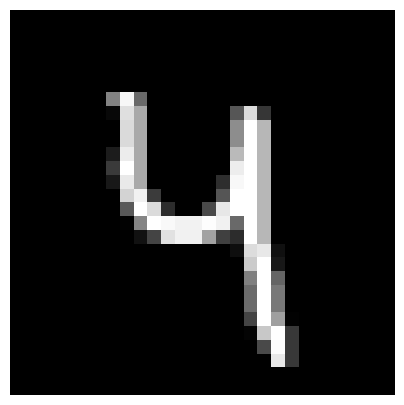

'Label: 4'

In [39]:
random_idx = np.random.randint(0, x_train.shape[0])
plot_number(x_train[random_idx])
display(f"Label: {y_train[random_idx].squeeze()}")

## Defining the Neural Network

In [40]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_size=784, hidden_size=200, output_size=10):
        super(FeedForwardNN, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

## Training the Neural Network

In [41]:
model = FeedForwardNN(input_size=784, hidden_size=200, output_size=10)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

loss_func = nn.CrossEntropyLoss()

In [44]:
num_epochs = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

train_losses = []
val_losses = []
val_accuracies = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for images, labels, in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = loss_func(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation loop
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = loss_func(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_accuracy = 100 * correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Feedback after each epoch
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f}")
    print(f"  Val Accuracy: {val_accuracy:.2f}%")


Epoch 1/10: 100%|██████████| 196/196 [00:03<00:00, 58.61it/s]


Epoch 1/10
  Train Loss: 0.0382
  Val Loss: 0.0780
  Val Accuracy: 97.52%


Epoch 2/10: 100%|██████████| 196/196 [00:02<00:00, 69.35it/s]


Epoch 2/10
  Train Loss: 0.0336
  Val Loss: 0.0825
  Val Accuracy: 97.41%


Epoch 3/10: 100%|██████████| 196/196 [00:02<00:00, 67.23it/s]


...

Epoch 8/10
  Train Loss: 0.0147
  Val Loss: 0.0728
  Val Accuracy: 97.66%


Epoch 9/10: 100%|██████████| 196/196 [00:03<00:00, 64.00it/s]


Epoch 9/10
  Train Loss: 0.0127
  Val Loss: 0.0721
  Val Accuracy: 97.91%


Epoch 10/10: 100%|██████████| 196/196 [00:02<00:00, 65.87it/s]


Epoch 10/10
  Train Loss: 0.0106
  Val Loss: 0.0722
  Val Accuracy: 97.74%


## Testing the model

With the model trained, we can now evaluate its performance on the test set. We will use the same accuracy function that we defined earlier to measure the accuracy of the model on the test set.

We can also visualize the confusion matrix.